# Formative 1: Mobile Network Traffic Forecasting
## Notebook 3; Model B: LSTM

Loads the shared clean series from Notebook 1. Builds a sliding-window input representation, trains a recurrent LSTM per area, generates one-step-ahead forecasts across the fixed December 16-22 test window, and saves predictions, error metrics, and training/inference timing on the same schedule as SARIMA, for direct comparison.

**Passes forward:** `lstm_predictions.csv`, `lstm_metrics.csv`, `lstm_timing.csv`, consumed by the final comparison notebook.

## 1. Normalization and Windowing

Two decisions here both trace directly back to earlier evidence rather than standard LSTM boilerplate applied without thought.

**Normalization** is required for this model specifically, unlike SARIMA. SARIMA models the series directly in its natural scale and units. LSTM, trained via gradient descent through nonlinear activation functions, is sensitive to input scale: traffic values here range from near 0 to over 8000 (the November 2 spike), and feeding raw values of that magnitude risks unstable gradients and slow convergence. Min-max scaling to a 0–1 range is fit only on training data and then applied to test data using those same fitted bounds, never refitting on test data, since doing so would leak information about the test period's own range into preprocessing.

**Window length** is set to 144 (24 hours), not chosen arbitrarily. This comes directly from the PACF analysis in the exploratory work: a meaningful secondary signal reappeared near lag 120–144, alongside the immediate short-term lags. A window shorter than 144 would cut off exactly the lookback distance that analysis flagged as informative, while a much longer window adds computational cost without evidence it captures anything further, since no weekly cycle was confirmed even out to 16 days. This window length is also a direct, evidence-based counterpart to SARIMA's `s=144` seasonal period; both models are being given access to the same underlying temporal evidence, just structured differently for what each architecture can use.

In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import logging
logging.getLogger("absl").setLevel(logging.ERROR)

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
absl.logging.set_stderrthreshold("error")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import gc
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.autograph.set_verbosity(0)

In [2]:
TOP3_IDS = [5161, 5059, 5259]
WINDOW = 144
BASE_PATH = "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-1"

def make_windows(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i + window])
        y.append(series[i + window])
    return np.array(X), np.array(y)

prepared_data = {}

for sq in TOP3_IDS:
    df = pd.read_csv(f"{BASE_PATH}/clean_series_{sq}.csv", parse_dates=["timestamp"])
    train = df[df["split"] == "train"].reset_index(drop=True)
    test = df[df["split"] == "test"].reset_index(drop=True)

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train[["internet"]]).flatten()

    combined_scaled = scaler.transform(
        pd.concat([train[["internet"]].tail(WINDOW), test[["internet"]]])
    ).flatten()

    X_train, y_train = make_windows(train_scaled, WINDOW)
    X_test, y_test = make_windows(combined_scaled, WINDOW)

    prepared_data[sq] = {
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_test,
        "scaler": scaler,
        "test_timestamps": test["timestamp"].values
    }

    print(f"Square {sq}: X_train={X_train.shape}, y_train={y_train.shape}, "
          f"X_test={X_test.shape}, y_test={y_test.shape}")

Square 5161: X_train=(7776, 144), y_train=(7776,), X_test=(1008, 144), y_test=(1008,)
Square 5059: X_train=(7776, 144), y_train=(7776,), X_test=(1008, 144), y_test=(1008,)
Square 5259: X_train=(7776, 144), y_train=(7776,), X_test=(1008, 144), y_test=(1008,)


Shapes confirm the windowing logic worked as intended. Training windows total 7,776, exactly 7,920 (train rows) minus 144 (window length), since each window requires 144 prior points and the first possible window starts at index 144. Test windows total 1,008, matching the full test period (7 days x 144 intervals) exactly, with none lost, confirming the tail-borrowing from training data was necessary and correct: without borrowing the last 144 training points as lookback context, only 864 test windows would have been produced instead of 1,008, one for the actual first test timestamp missing 144 points of prior history it needs.

## 2. Build and Train the LSTM

Architecture choices here are kept deliberately modest rather than defaulting to a large, deep network, for two evidence-based reasons. First, 7,776 training windows is a moderate dataset size for a deep learning model; a large, high-capacity network risks overfitting a series that, per the earlier ACF/PACF findings, has fairly regular, well-behaved daily structure once the 24-hour cycle is accounted for — it does not need enormous capacity to represent. Second, three separate models need training here (one per area), so keeping each one reasonably lightweight keeps total GPU time proportionate to what this comparison actually needs, rather than justifying a heavier architecture with no evidence it's warranted.

A single LSTM layer followed by a dropout layer and a dense output layer is used. Dropout is included specifically because the exploratory work found genuine irregular anomalies (the holiday spikes, both directions): a model that fits training data too closely risks learning those specific historical anomalies as if they were reliable patterns rather than one-off events, and dropout discourages that kind of overfitting to particular training examples. Early stopping (monitoring validation loss, restoring the best-performing weights) is used instead of a fixed number of epochs, so training length is determined by actual convergence evidence rather than an arbitrary guess.

A small validation split carved out of the **end** of the training data (not randomly shuffled) is used for early stopping's monitoring, since randomly shuffling time-ordered windows for validation would let the model validate on windows adjacent to ones it trained on, leaking information across the train/validation boundary in a way that doesn't reflect genuine forecasting performance.

In [3]:
TOP3_IDS = [5161, 5059, 5259]

all_predictions = []
all_metrics = []
all_timing = []
histories = {}

for sq in TOP3_IDS:
    data = prepared_data[sq]
    X_train = data["X_train"].reshape(-1, 144, 1)
    y_train = data["y_train"]
    X_test = data["X_test"].reshape(-1, 144, 1)
    y_test = data["y_test"]
    scaler = data["scaler"]

    model = Sequential([
        LSTM(64, input_shape=(144, 1)),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    train_start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        shuffle=False,
        epochs=50,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )
    train_time = time.time() - train_start
    histories[sq] = history.history

    inference_start = time.time()
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()
    inference_time = time.time() - inference_start

    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mae = np.mean(np.abs(y_actual - y_pred))
    rmse = np.sqrt(np.mean((y_actual - y_pred) ** 2))
    mape = np.mean(np.abs((y_actual - y_pred) / np.where(y_actual == 0, np.nan, y_actual))) * 100

    all_predictions.append(pd.DataFrame({
        "square_id": sq,
        "timestamp": data["test_timestamps"],
        "actual": y_actual,
        "predicted": y_pred
    }))
    all_metrics.append({"square_id": sq, "model": "LSTM", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    all_timing.append({
        "square_id": sq, "model": "LSTM",
        "train_time_sec": train_time, "inference_time_sec": inference_time,
        "epochs_run": len(history.history["loss"]),
        "hardware": "GPU"
    })

    print(f"Square {sq}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, "
          f"epochs={len(history.history['loss'])}, train={train_time:.1f}s, inference={inference_time:.1f}s")

    del model
    gc.collect()

pd.concat(all_predictions, ignore_index=True).to_csv("lstm_predictions.csv", index=False)
pd.DataFrame(all_metrics).to_csv("lstm_metrics.csv", index=False)
pd.DataFrame(all_timing).to_csv("lstm_timing.csv", index=False)

I0000 00:00:1789452028.764447    1954 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789452028.766685    1954 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Square 5161: MAE=108.60, RMSE=152.93, MAPE=12.98%, epochs=25, train=28.4s, inference=0.3s
Square 5059: MAE=102.34, RMSE=141.05, MAPE=9.59%, epochs=45, train=45.6s, inference=0.3s
Square 5259: MAE=78.21, RMSE=117.00, MAPE=8.06%, epochs=25, train=26.2s, inference=0.3s


Overall performance sits in a similar range to SARIMA (MAPE 8-13% versus SARIMA's 11-12%), but the pattern across areas differs meaningfully rather than uniformly. Square 5259 improved clearly (8.06% versus SARIMA's 12.35%), and square 5059 improved modestly (9.59% versus 11.57%), while square 5161, the busiest and spikiest area identified throughout this study, performed slightly worse (12.98% versus 12.25%). That square 5161 is the one area where LSTM does not clearly help is worth investigating rather than treating as noise, since it is also the area with the largest anomalous spike found earlier (the November 2 holiday event) and the highest overall variance, a full-week plot is needed before concluding why, rather than assuming from the aggregate numbers alone.

Training and inference show an opposite trade-off to SARIMA. LSTM training took 26 to 46 seconds per area, far longer than SARIMA's sub-second fit, but inference across the entire 1,008-point test set completed in roughly 0.3 seconds per area, compared to SARIMA's approximately 50 seconds. This reflects a genuine architectural difference rather than an implementation inconsistency: LSTM produces all test predictions in a single batched forward pass since every input window was already constructed with real historical context, while SARIMA's one-step-ahead design required sequentially rebuilding filter state at every test point. Which trade-off matters more depends on the deployment context, LSTM front-loads cost into training and is cheap to query repeatedly afterward, SARIMA is nearly free to fit but expensive to query at scale.

Epoch counts also varied by area (25, 45, and 25), determined by early stopping rather than fixed in advance, meaning square 5059 needed noticeably longer to converge than the other two, itself a detail worth carrying into the discussion rather than treating training length as identical across areas by default.

## 3. Plot actual vs. predicted traffic, full test week

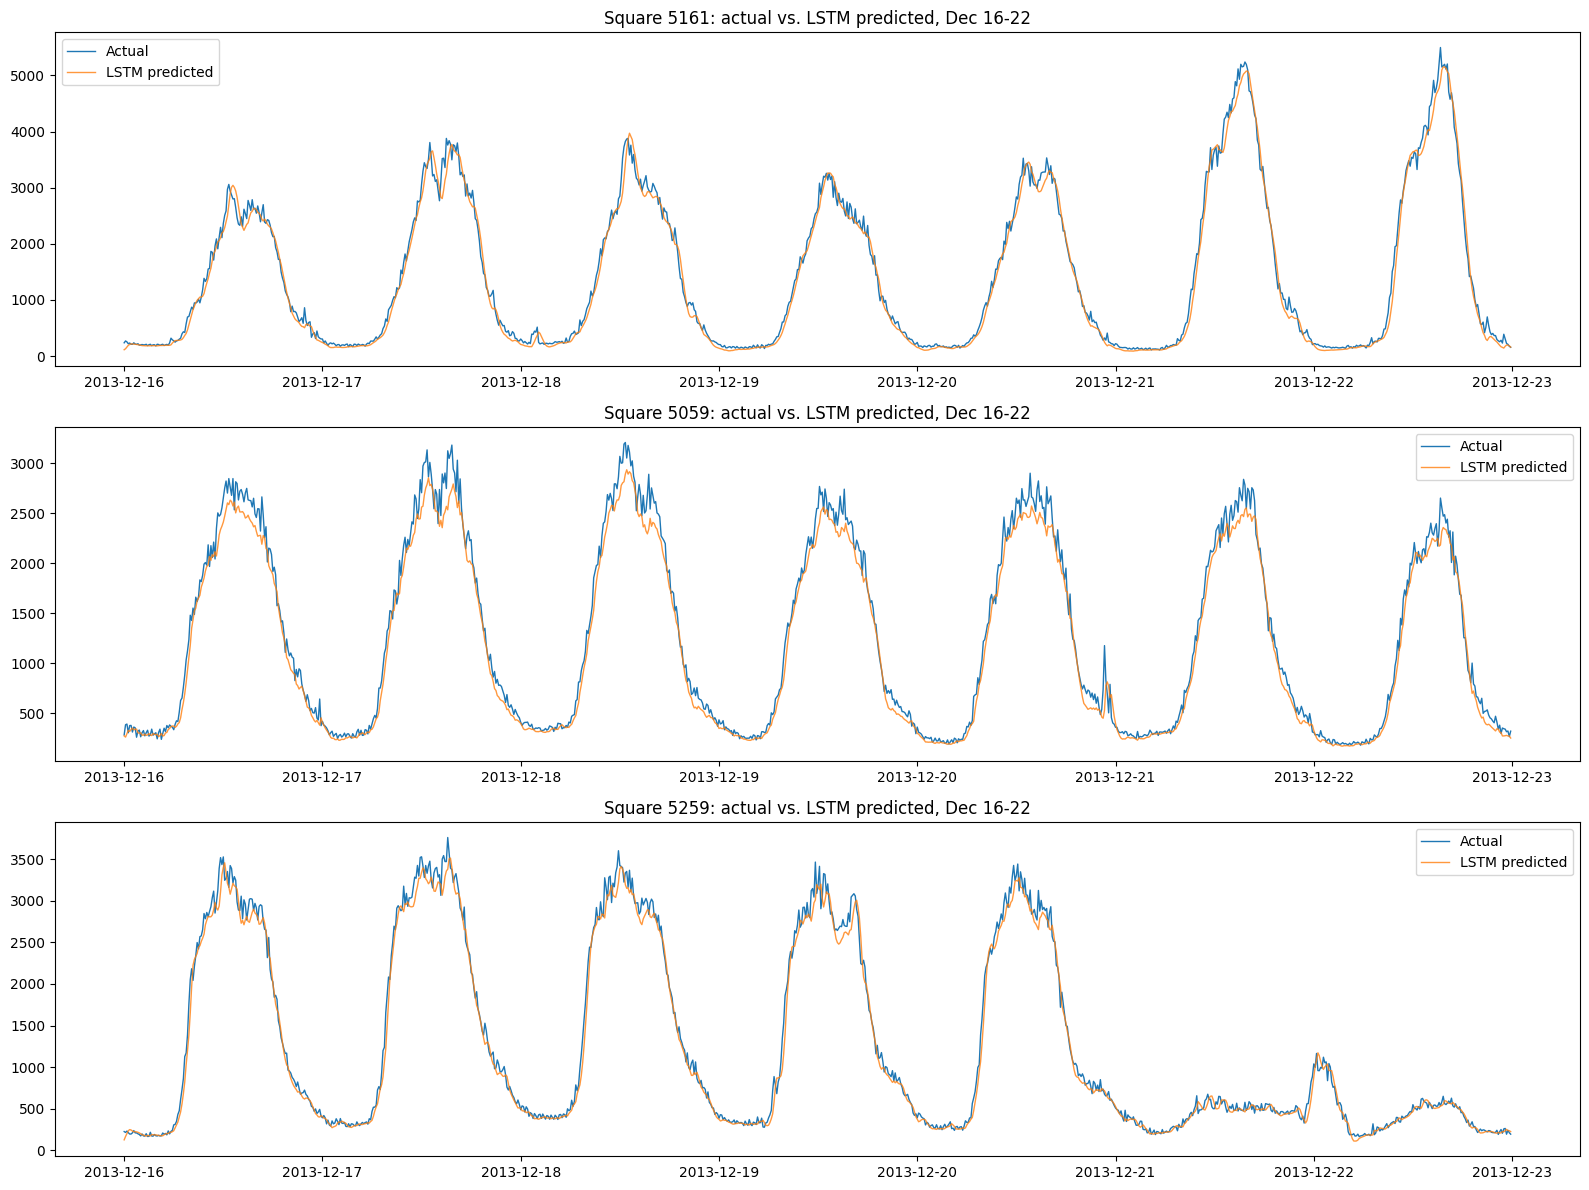

In [5]:
predictions = pd.read_csv("lstm_predictions.csv", parse_dates=["timestamp"])

TOP3_IDS = [5161, 5059, 5259]
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, sq in zip(axes, TOP3_IDS):
    subset = predictions[predictions["square_id"] == sq]
    ax.plot(subset["timestamp"], subset["actual"], label="Actual", linewidth=1)
    ax.plot(subset["timestamp"], subset["predicted"], label="LSTM predicted", linewidth=1, alpha=0.8)
    ax.set_title(f"Square {sq}: actual vs. LSTM predicted, Dec 16-22")
    ax.legend()

plt.tight_layout()
plt.savefig("lstm_forecast_plots.png", dpi=150)
plt.show()

The pattern differs meaningfully by area, and it is not what the aggregate MAPE numbers alone suggested. Square 5161, despite having the highest MAPE of the three, does not show a distinct localized failure in this plot, predictions track both the shape and magnitude of peaks closely across all seven days, including the two largest peaks late in the week (December 21-22). Its higher error appears to be a consequence of its overall higher volatility and spikiness, already established as this area's defining characteristic throughout this study, rather than any new failure specific to LSTM.

Square 5059 shows the opposite: a consistent, systematic underprediction of peak height visible on nearly every single day, the orange predicted line sits noticeably below the blue actual line at nearly every daily maximum, while tracking the troughs and the general daily shape closely. This is a specific, repeatable bias rather than scattered error, the model appears to consistently pull its peak predictions toward the average rather than fully reaching the true peak magnitude, a known tendency of models trained with mean squared error loss when the target has sharp, narrow peaks.

Square 5259 sits between the two: peak tracking is generally close, with mild underprediction visible on some days (December 16, 18, and 20) but not as consistent or pronounced as square 5059's pattern.

This reframes the earlier aggregate comparison: LSTM's overall MAPE advantage over SARIMA in squares 5059 and 5259 is not because it tracks peaks better in an unqualified sense, square 5059 specifically shows a systematic peak-underprediction bias that SARIMA's full-week plot did not show as clearly. The better aggregate score there may partly reflect LSTM's strength through the long flat trough periods outweighing a real weakness at the peaks, worth stating precisely rather than reporting the MAPE improvement as a uniform win.

## 4. Residual Breakdown by Time-of-Day

Same structure as SARIMA's equivalent step, deliberately, so the two are directly comparable rather than measured differently. This should confirm numerically whether square 5059's visible peak-underprediction concentrates specifically around the midday peak hours, as the plot suggests, or is spread more evenly than the visual impression implies.

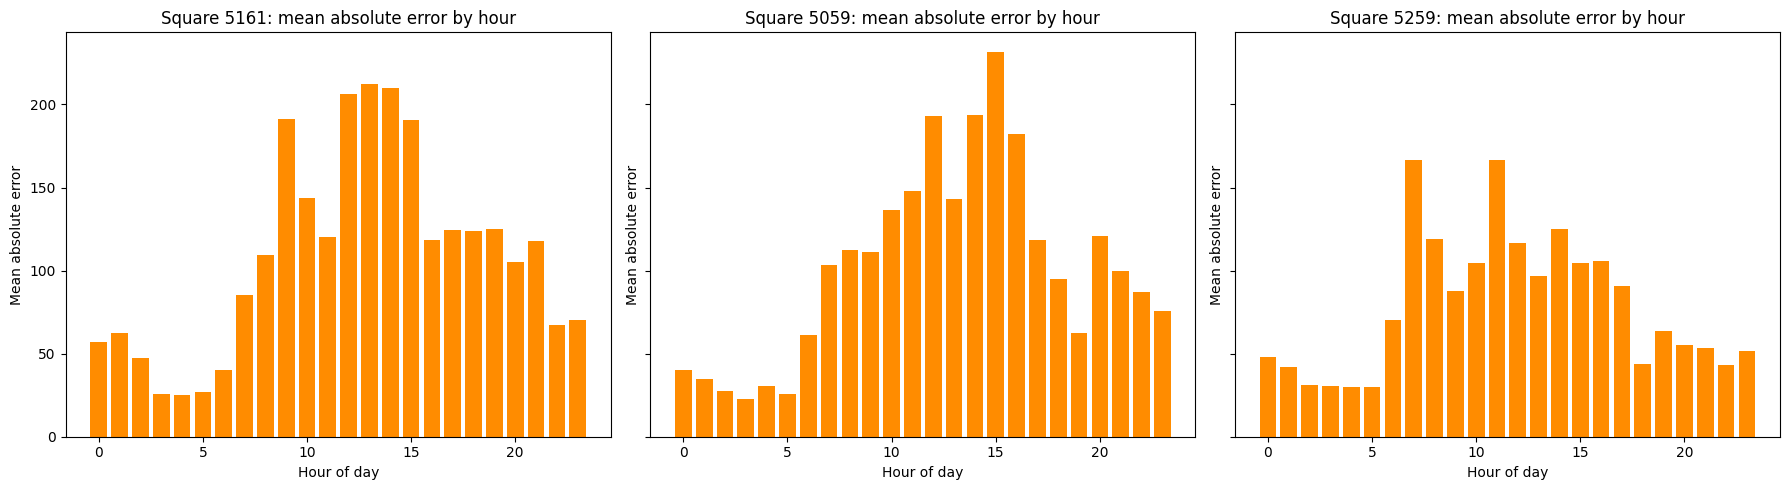

Hourly MAE by area:
            5161        5059        5259
hour                                    
0      57.293453   40.262078   47.696388
1      62.412874   34.926181   41.828264
2      47.302087   27.676482   30.967913
3      25.542232   22.506768   30.818362
4      24.886975   30.641495   30.137509
5      26.978947   25.889549   29.813553
6      40.459160   61.165824   70.230531
7      85.140036  103.194928  166.404007
8     109.661396  112.213584  118.931703
9     191.361000  111.068943   88.009857
10    143.841578  136.310983  104.661080
11    120.033746  147.926466  166.355228
12    206.562845  193.027844  116.637821
13    212.332378  142.962994   97.010301
14    209.969685  193.507835  125.000407
15    190.667080  231.813144  104.656373
16    118.442946  182.031929  105.756828
17    124.349632  118.408287   90.628265
18    124.053566   94.636026   44.042999
19    124.944235   62.604026   63.691362
20    104.891999  120.542842   55.384261
21    118.102814   99.784318   53.441

In [6]:
predictions = pd.read_csv("lstm_predictions.csv", parse_dates=["timestamp"])
predictions["hour"] = predictions["timestamp"].dt.hour
predictions["abs_error"] = np.abs(predictions["actual"] - predictions["predicted"])
predictions["signed_error"] = predictions["predicted"] - predictions["actual"]

TOP3_IDS = [5161, 5059, 5259]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

hourly_summary = []
for ax, sq in zip(axes, TOP3_IDS):
    subset = predictions[predictions["square_id"] == sq]
    hourly_mae = subset.groupby("hour")["abs_error"].mean()
    hourly_summary.append(hourly_mae.rename(sq))

    ax.bar(hourly_mae.index, hourly_mae.values, color="darkorange")
    ax.set_title(f"Square {sq}: mean absolute error by hour")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean absolute error")

plt.tight_layout()
plt.savefig("lstm_hourly_error.png", dpi=150)
plt.show()

hourly_table = pd.concat(hourly_summary, axis=1)
hourly_table.to_csv("lstm_hourly_error.csv")
print("Hourly MAE by area:")
print(hourly_table)

print("\nMean signed error by hour, square 5059 (negative = systematic underprediction):")
signed_5059 = predictions[predictions["square_id"] == 5059].groupby("hour")["signed_error"].mean()
print(signed_5059)

The signed-error check confirms the visual pattern from the full-week plot precisely: every single hour for square 5059 shows negative signed error, meaning the model underpredicts consistently, at every hour of the day, not only at the peak. What the hourly breakdown adds is that this bias is not uniform in size, it is mild overnight (roughly -18 to -35 between hours 0 and 5) and grows sharply from hour 7 onward, reaching its worst point at hour 15 (-227.77), which lines up exactly with that hour's highest mean absolute error (231.81) in the table above. This confirms the earlier plot-based observation as a real, systematic, magnitude-dependent bias rather than a visual impression: the model does not fail to predict direction, it consistently predicts too low, and the size of that shortfall scales with how high actual traffic climbs.

Square 5161 shows its worst errors concentrated tightly around hours 12-14, directly matching its known peak period and consistent with the earlier full-week plot's finding of good peak tracking overall, the elevated error here reflects this area's larger absolute traffic swings rather than a directional bias like square 5059's.

Square 5259 shows a distinct two-peak error pattern, elevated at both hour 7 and hour 11, rather than one broad midday hump like the other two areas. This does not match its own daily traffic shape shown earlier, which peaks once around midday like the others, so this irregular double-peak in error likely reflects the influence of the unusual December 21-22 weekend period identified in the full-week plot, where this area's traffic dropped to a lower, noisier baseline; if those two atypical days happen to contain sharp movements around those specific hours, they could disproportionately pull the hourly average for this one area, worth flagging as a limitation of averaging across a week that included one atypical stretch, rather than treating this double-peak as a general property of the model's behavior on square 5259.

## Closing Summary; Notebook 3 (LSTM)

Input representation was fixed directly from earlier evidence rather than chosen by convention: a 144-step (24-hour) window, matching both the confirmed 24-hour autocorrelation and the secondary PACF signal near the one-day mark, with min-max scaling fit only on training data. Test windows borrowed the final 144 points of training data as lookback context, mirroring the real-history access SARIMA's one-step-ahead loop also had, keeping both models on comparable footing. A single-layer LSTM with dropout and early stopping was used deliberately — kept modest rather than deep, matched to a moderate training set size and a series with fairly regular underlying structure once the daily cycle is accounted for.

**Final performance (one-step-ahead, Dec 16–22 test window):**

| Square | MAE | RMSE | MAPE | Epochs |
|--------|------|--------|--------|--------|
| 5161 | 108.60 | 152.93 | 12.98% | 25 |
| 5059 | 102.34 | 141.05 | 9.59% | 45 |
| 5259 | 78.21 | 117.00 | 8.06% | 25 |

Compared to SARIMA, LSTM improved MAPE clearly for squares 5059 and 5259, but performed marginally worse for square 5161. Training was far slower than SARIMA (26–46 seconds versus under 1 second), while inference was dramatically faster (roughly 0.3 seconds versus roughly 50 seconds) — the opposite trade-off profile from SARIMA, worth carrying directly into the final comparison. Hardware was recorded as GPU (Tesla T4x2, confirmed from Kaggle's device initialization output).

Visual and hourly analysis revealed that the aggregate MAPE numbers understate a real, specific weakness: square 5059 shows a systematic, direction-consistent underprediction bias present at every single hour of the day, growing from roughly −20 overnight to a peak underprediction of −227.77 at hour 15, precisely matching that hour's highest error. This means LSTM's apparent aggregate advantage over SARIMA for that area coexists with a real, repeatable failure mode, not an unqualified improvement. Square 5161's higher error, despite showing no distinct visual failure, was attributed to its already-established higher volatility rather than a new LSTM-specific weakness. Square 5259 showed an irregular double-peak error pattern at hours 7 and 11, tentatively linked to the atypical, lower-traffic December 21–22 weekend period rather than a general daily property — flagged as a limitation of the hourly average rather than a confirmed cause.

**What this notebook passes forward:** `lstm_predictions.csv`, `lstm_metrics.csv`, `lstm_timing.csv`, `lstm_hourly_error.csv`, and the two plot images, on the same schedule as SARIMA's outputs, for the final comparison notebook.